# This notebook takes the one instruction sequences taken when values are zero and surrounded by nops and places them into a Training Dataset.
- Note some datasets will use similar codes EM signals that was found to perform very similar, if not the same, executions and created the same EM range.
- Example and, andi, which both performs the and operations, just one takes the immediate value and another takes the value in a register.

# Import

In [1]:
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import random
import tensorflow as tf
import numpy as np
import timeit
from sklearn import metrics
import scipy.io as sio
import csv
import os
import math 
import random as rand
from numpy import genfromtxt
from numpy import sum,isrealobj,sqrt
from numpy.random import standard_normal

#import torch
#from torch import nn

import warnings
from scipy.spatial import distance



import sys
sys.path.append("..") # Adds higher directory to python modules path.

from Modules.Tools import MapTool
from Modules.Tools import BoxPlot
from Modules.Tools import peakCorrelation as pC

In [2]:
# Signal 
params = {'legend.fontsize': 50,
          'figure.figsize': (45, 15),
         'axes.labelsize': 60,
         'axes.titlesize':70,
         'xtick.labelsize':50,
         'ytick.labelsize':50,
         'lines.linewidth': 8}
plt.rcParams.update(params)

# Notebook Parameters
- this is simply for obtaining the graphs with manual mapping. Pad is closely relate to the sampling rate for the EM signal

In [3]:
save_folder = "./Graphs/6_0_1_One Inst/"
load_folder = "./Datasets/Numpy/Nops Inst Nops/Full_Signals/"
pad = 8
y_low=-2.8
y_high=2.8
amount=1500

In [4]:
def getValue(dataset, loc):
    list_peaks = []
    
    for peaks in dataset:
        list_peaks.append(peaks[loc])
    return np.array(list_peaks)

# Load Datasets
- we will only load the EM signals for code examples who shows in Alpha, Bravo, Charlie, Delta and Echo

In [5]:
load_Dataset_Folder = "./Datasets/FP_GANs_LargeScale_2/k-Fold/TrainingDatasets/"
All_Code = np.load(load_Dataset_Folder + "All_Code.npy", allow_pickle = True)

In [6]:
all_instructions = All_Code[0] 

sentence_Code = [all_instructions]

print(sentence_Code)

['add, and, andi, brneF, brneTPT1, brneTPT2, brplF, bset, cli, cln, com, cp, dec, eor, fmulPT1, fmulPT2, in, inc, jmpPT1, jmpPT2, jmpPT3, ldi, ldsPT1, ldsPT2, mov, mulsPT1, mulsPT2, neg, nop, or, ori, out, popPT1, popPT2, pushPT1, pushPT2, sbc, sbci, sbisF, sen, sev, stsPT1, stsPT2, sub, swap, tst']


In [7]:
# Removing split code
code_Names = ['add', 
                 'and', 
                 'andi', 
                 'brneF', 
                 'brneT', 
                 'brplF', 
                 'bset', 
                 'cli', 
                 'cln', 
                 'com', 
                 'cp', 
                 'dec', 
                 'eor', 
                 'fmul', 
                 'in', 
                 'inc', 
                 'jmp', 
                 'ldi', 
                 'lds', 
                 'mov', 
                 'muls',
                 'neg', 
                 'nop', 
                 'or', 
                 'ori', 
                 'out', 
                 'pop',
                 'push', 
                 'sbc', 
                 'sbci', 
                 'sbisF', 
                 'sen', 
                 'sev', 
                 'sts', 
                 'sub', 
                 'swap', 
                 'tst']

## Single Cycle

In [8]:
load_Folder = "./Datasets/Numpy/Nops Inst Nops/All_Peaks-avg_norm/"

In [9]:
add = np.load(load_Folder + 'Arithmetic_and_Logic/add_peaks.npy', allow_pickle=True)
# will be used for and and andi
andd = np.load(load_Folder + 'Arithmetic_and_Logic/and_peaks.npy', allow_pickle=True)
brne_f = np.load(load_Folder + 'Branch/brne_false_peaks.npy', allow_pickle=True)
brpl_f = np.load(load_Folder + 'Branch/brpl_false_peaks.npy', allow_pickle=True)
bset = np.load(load_Folder + 'Bit_and_Bit/bset_peaks.npy', allow_pickle=True)
# will be used for cli and cln (all clears a flag value)
clc = np.load(load_Folder + 'Bit_and_Bit/clc_peaks.npy', allow_pickle=True)
com = np.load(load_Folder + 'Arithmetic_and_Logic/com_peaks.npy', allow_pickle=True)
cp = np.load(load_Folder + 'Branch/cp_peaks.npy', allow_pickle=True)
dec = np.load(load_Folder + 'Arithmetic_and_Logic/dec_peaks.npy', allow_pickle=True)
eor = np.load(load_Folder + 'Arithmetic_and_Logic/eor_peaks.npy', allow_pickle=True)
inn = np.load(load_Folder + 'Data Transfer/in_peaks.npy', allow_pickle=True)
inc = np.load(load_Folder + 'Arithmetic_and_Logic/inc_peaks.npy', allow_pickle=True)
ldi = np.load(load_Folder + 'Data Transfer/ldi_peaks.npy', allow_pickle=True)
mov = np.load(load_Folder + 'Data Transfer/mov_peaks.npy', allow_pickle=True)
neg = np.load(load_Folder + 'Arithmetic_and_Logic/neg_peaks.npy', allow_pickle=True)
nop = np.load(load_Folder + 'MCU_Control/nop_peaks.npy', allow_pickle=True)
# will be used for or and ori
orr = np.load(load_Folder + 'Arithmetic_and_Logic/or_peaks.npy', allow_pickle=True)
out = np.load(load_Folder + 'Data Transfer/out_peaks.npy', allow_pickle=True)
# will be used for sub, sbc (subtract with carry) and sbci (subtract immediate with carry)
sub = np.load(load_Folder + 'Arithmetic_and_Logic/sub_peaks.npy', allow_pickle=True)
# will be used for sen and sev, sets a flag.
sec = np.load(load_Folder + 'Bit_and_Bit/sec_peaks.npy', allow_pickle=True)
# will be used for sbisF, both skips based on if bit in register is set or not set.
sbrc_f = np.load(load_Folder + 'Branch/sbrc_false_peaks.npy', allow_pickle=True)
swap = np.load(load_Folder + 'Bit_and_Bit/swap_peaks.npy', allow_pickle=True)
tst = np.load(load_Folder + 'Arithmetic_and_Logic/tst_peaks.npy', allow_pickle=True)

## Double Cycles

In [10]:
brne_t = np.load(load_Folder + 'Branch/brne_true_peaks.npy', allow_pickle=True)
mul = np.load(load_Folder + 'Arithmetic_and_Logic/mul_peaks.npy', allow_pickle=True)
fmul = np.load(load_Folder + 'Arithmetic_and_Logic/fmul_peaks.npy', allow_pickle=True)
lds = np.load(load_Folder + 'Data Transfer/lds_peaks.npy', allow_pickle=True)
push = np.load(load_Folder + 'Data Transfer/push_peaks.npy', allow_pickle=True)
pop = np.load(load_Folder + 'Data Transfer/pop_peaks.npy', allow_pickle=True)
sts = np.load(load_Folder + 'Data Transfer/sts_peaks.npy', allow_pickle=True)

## Triple Cycles

In [11]:
jmp = np.load(load_Folder + 'Branch/jmp_peaks.npy', allow_pickle=True)

In [13]:
add_Test_Range = np.load("./Datasets/Numpy/Nops Inst Nops/Full_Signals-avg_norm/Arithmetic_and_Logic/add_full.npy", allow_pickle=True)
alpha = np.load("./Datasets/Numpy/FP_GANs_LargeScale_2/full/Alpha/Alpha_full.npy", allow_pickle=True)

In [14]:
seq_list = [add, andd, andd, brne_f, brne_t, brpl_f, bset, clc, clc, com, cp, dec, eor, fmul, inn, inc, jmp, 
            ldi, lds, mov, mul, neg, nop, orr, orr, out, pop, push, sub, sub, sub, sec, sec, sts, sub, swap, tst]

In [15]:
len(code_Names)

37

In [16]:
len(seq_list)

37

# Test Range
-- checks to see if the values are normalized

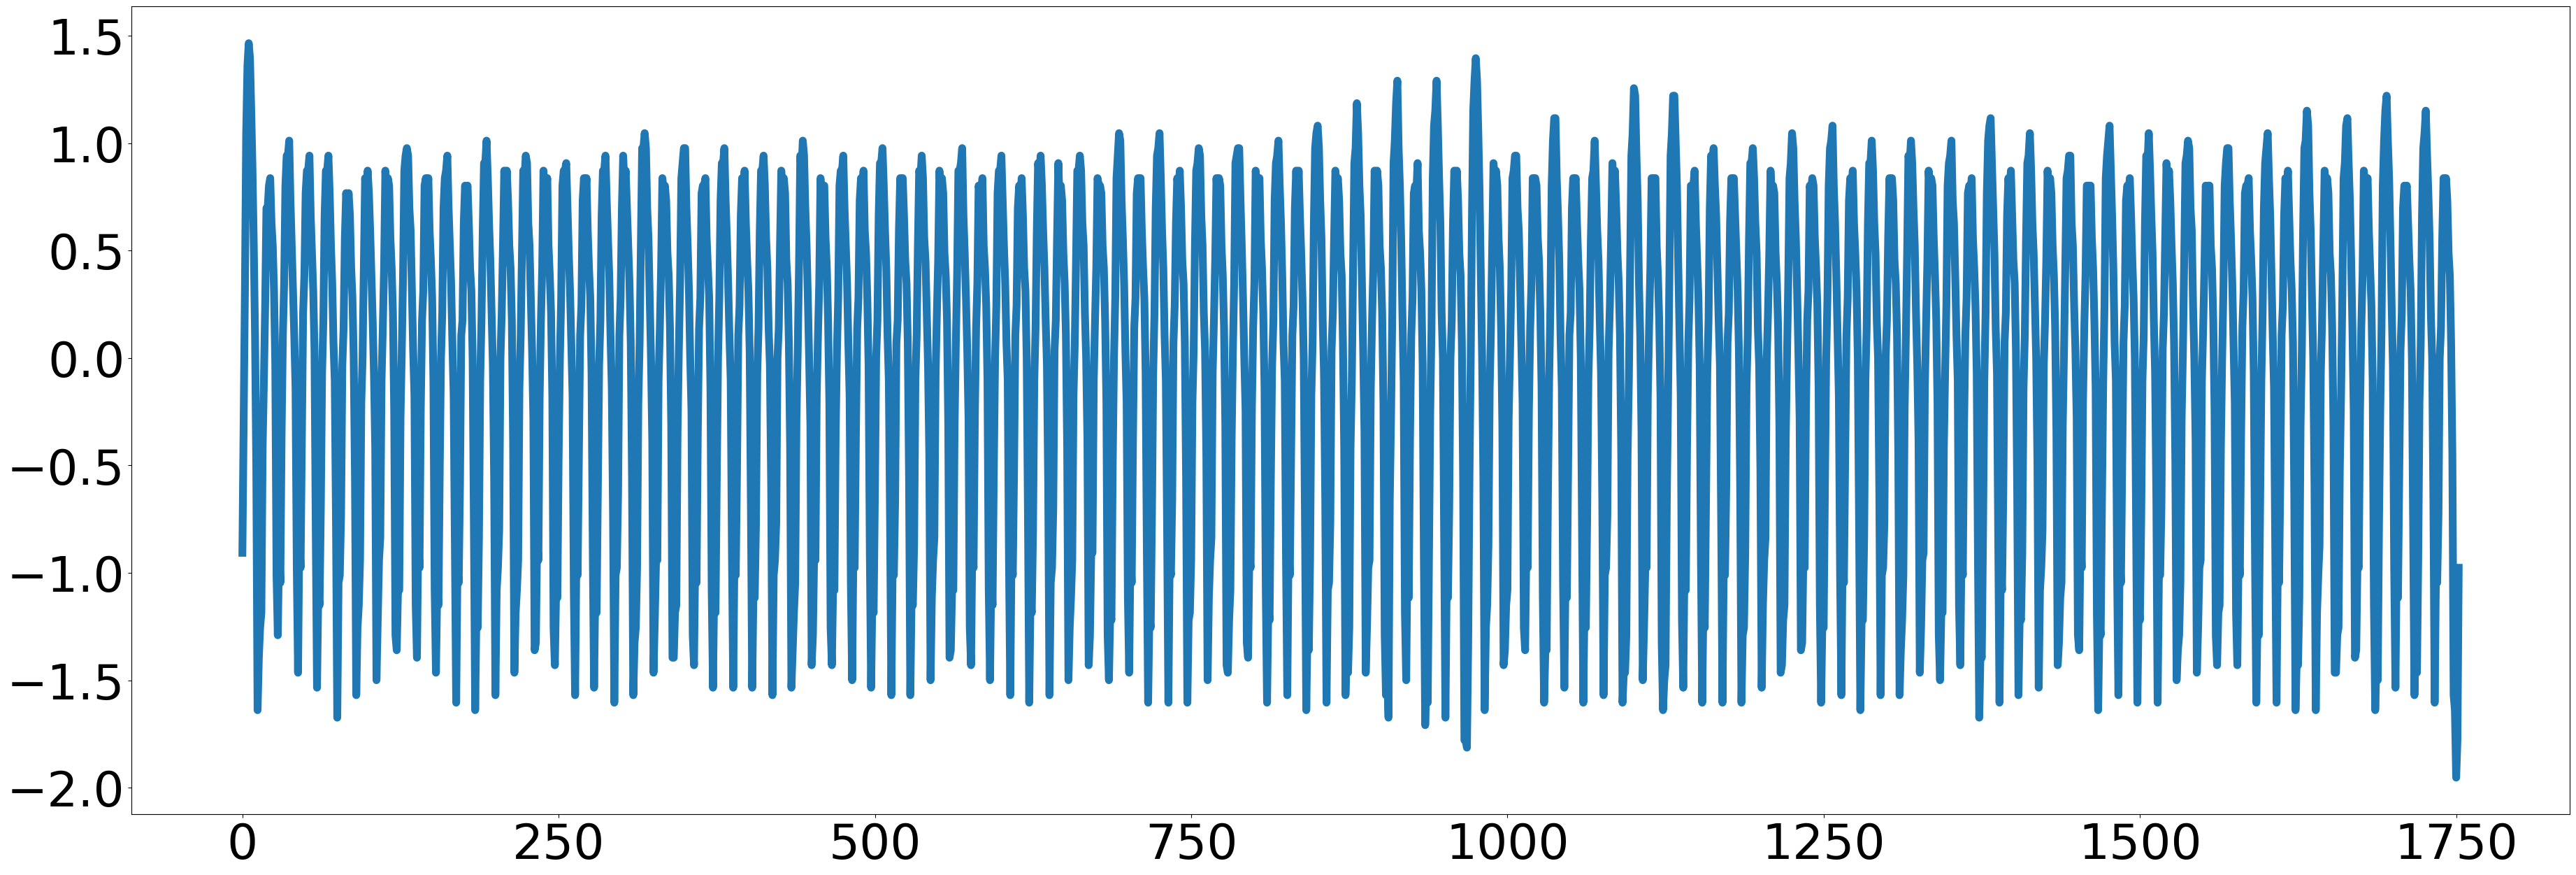

In [17]:
plt.plot(add_Test_Range[0])
plt.show()

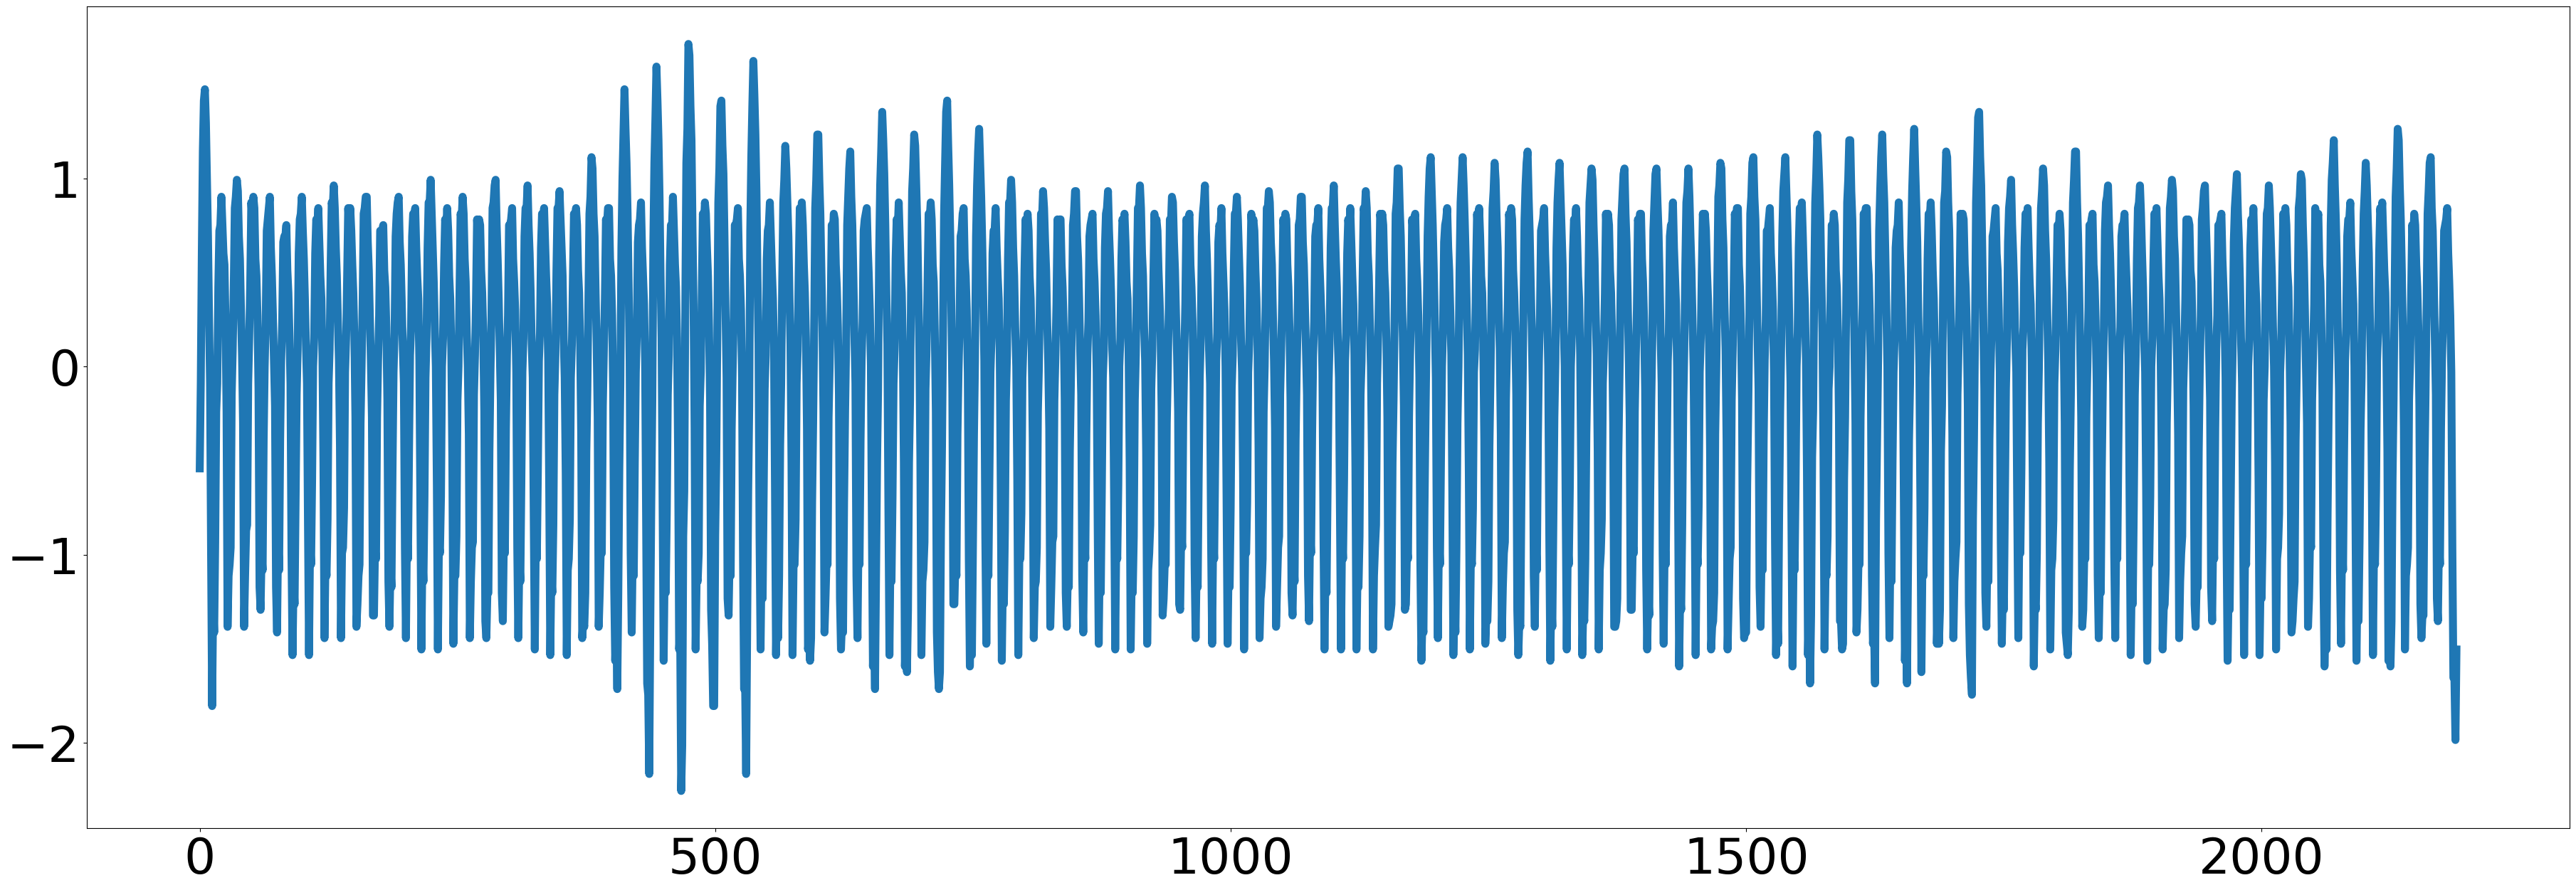

In [18]:
plt.plot(alpha[0])
plt.show()

# Manual Mapping Signals

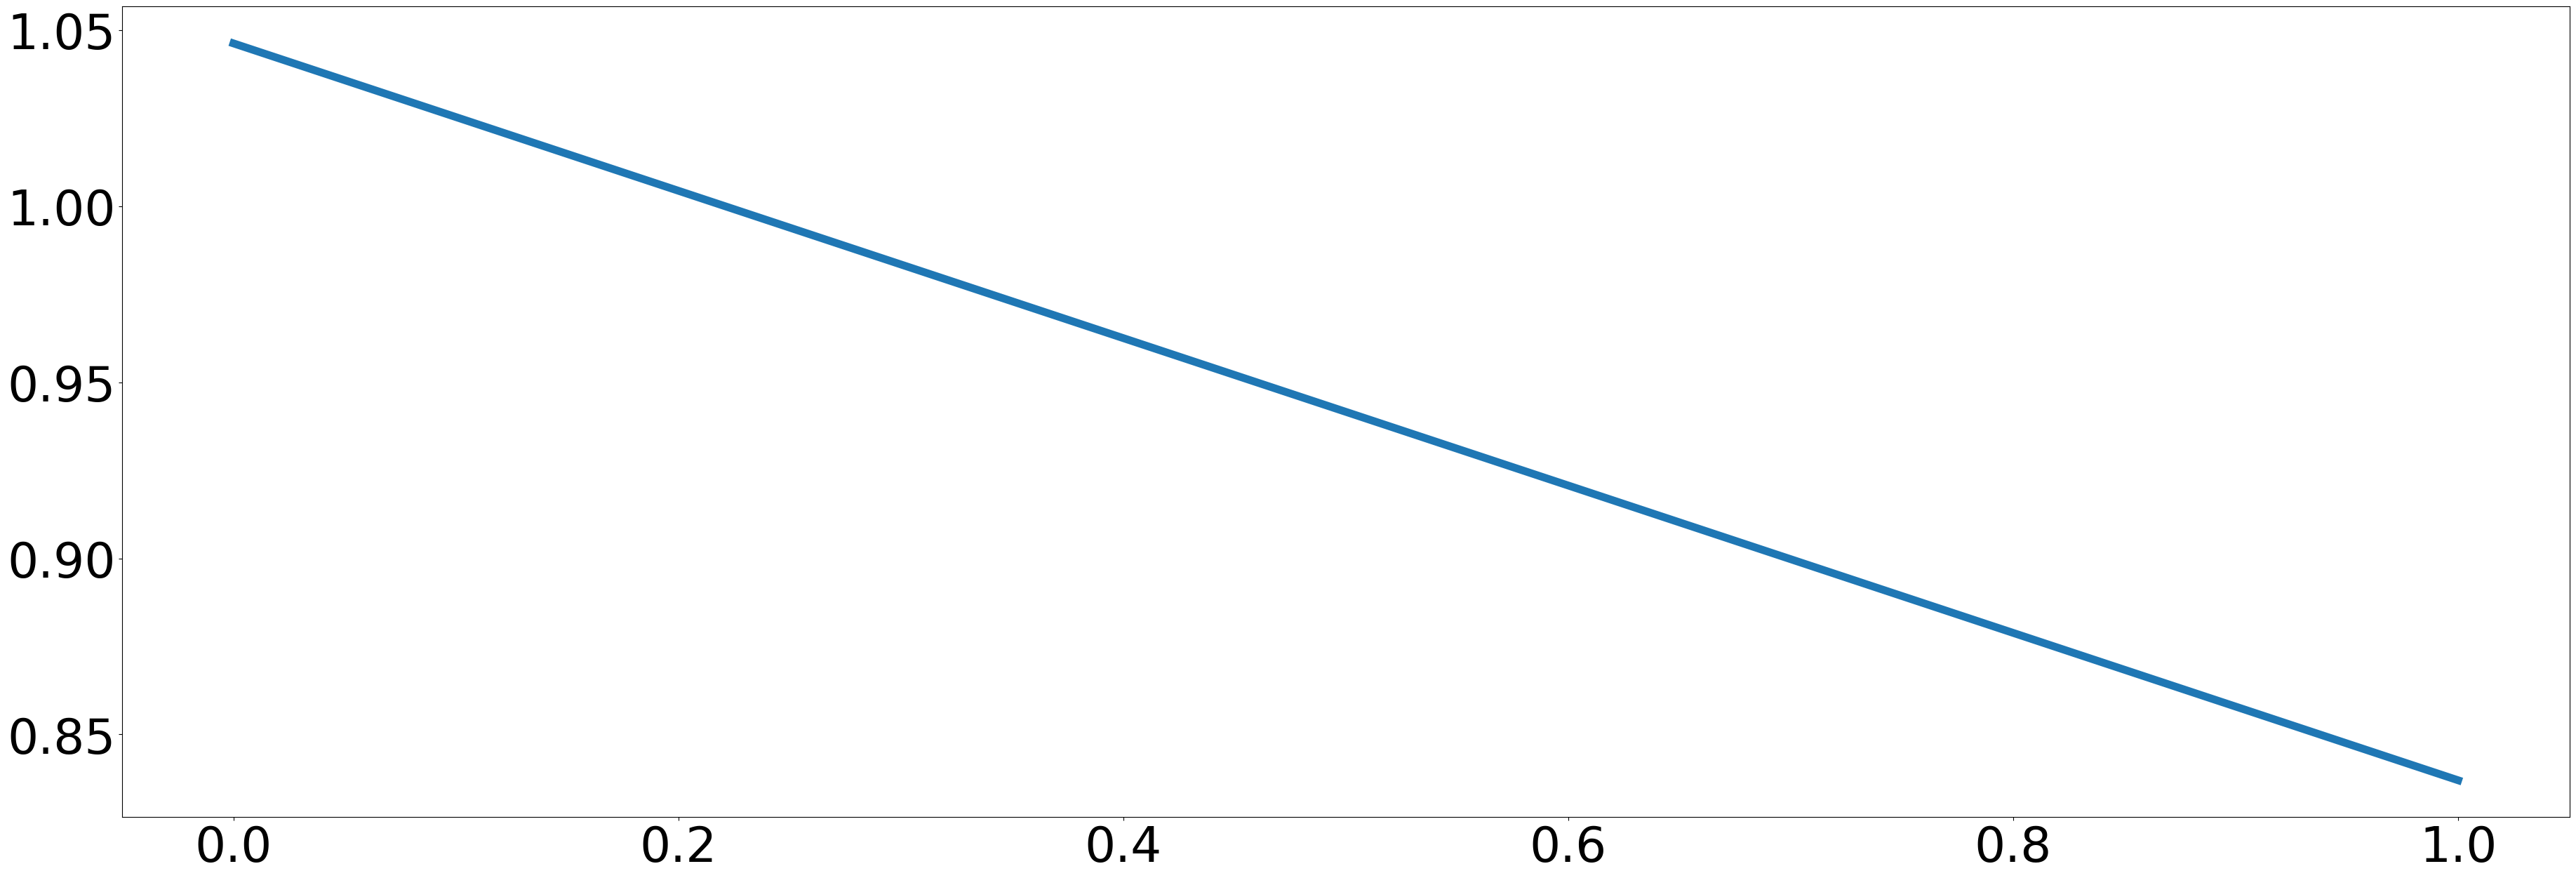

In [19]:
plt.plot(add[0])
plt.show()

## Note the saved information has all peaks, not just the major peaks. As such, we will have to select the correct peaks when saving.

In [20]:
print(add.shape)
for n in range(10):
    print(add[n])

(500, 2)
[1.0463053971929945 0.8369705506743786]
[1.0463053971929945 0.8369705506743786]
[1.0811739143663663 0.8369705506743786]
[1.0463053971929945 0.8369705506743786]
[1.0463053971929945 0.8718390678477507]
[1.0114368800196223 0.8369705506743786]
[1.0114368800196223 0.8369705506743786]
[1.0811739143663663 0.8718390678477507]
[1.0114368800196223 0.8718390678477507]
[1.0811739143663663 0.8021020335010066]


In [21]:
temp = add[:,0]
print(temp.shape)
for n in range(10):
    print(temp[n])

(500,)
1.0463053971929945
1.0463053971929945
1.0811739143663663
1.0463053971929945
1.0463053971929945
1.0114368800196223
1.0114368800196223
1.0811739143663663
1.0114368800196223
1.0811739143663663


## Code splitting multi-cycles instructions into individual cycles.

# Method

In [22]:
'''
Return a dictionary of (A) the major peaks of the instructions cycle and (B) the names of the instuction 
being executed in the sequence. I.E. {Data: [], Code: []}

Parameters
Signals: the EM peaks.
Signals_Names: names of the instructions in the Signals_1C (MUST BE IN THE SAME ORDER AS Signals_1C)
'''
def createTS(Signals, Signals_Names):
    # list object to contain the dictionry information.
    listOfInfo = []
    
    code_list = []
    two_cycle_list = ["sts", "lds", "muls", "fmul", "push", "pop", "brneT"]
    three_cycle_list = ["jmp"]
    
    for n in range(len(Signals_Names)):
        code = Signals_Names[n]
        
        # check for hyphens
        if Signals_Names[n] == "brne-f":
            code = "brneF"
        elif Signals_Names[n] == "brne-t":
            code = "brneT"
        elif Signals_Names[n] == "brpl-f":
            code = "brplF" 
        elif Signals_Names[n] == "sbis-f":
            code = "sbisF"
        
        # check for two cycles
        elif code in two_cycle_list:
            codeR = code + "PT1"
            seqCode = [codeR]
            seqs = np.reshape(Signals[n][:,0], (-1,1))
            
            dictPair = {"Seq": seqs, "Code": seqCode}
            listOfInfo.append(dictPair)
            
            codeR = code + "PT2"
            seqCode = [codeR]
            seqs = np.reshape(Signals[n][:,2], (-1,1))
            
            dictPair = {"Seq": seqs, "Code": seqCode}
            listOfInfo.append(dictPair)
            
        # check for thee cycles
        elif code in three_cycle_list:
            codeR = code + "PT1"
            seqCode = [codeR]
            seqs = np.reshape(Signals[n][:,0], (-1,1))
            
            dictPair = {"Seq": seqs, "Code": seqCode}
            listOfInfo.append(dictPair)
            
            codeR = code + "PT2"
            seqCode = [codeR]
            seqs = np.reshape(Signals[n][:,2], (-1,1))
            
            dictPair = {"Seq": seqs, "Code": seqCode}
            listOfInfo.append(dictPair)
            
            codeR = code + "PT3"
            seqCode = [codeR]
            seqs = np.reshape(Signals[n][:,4], (-1,1))
            
            dictPair = {"Seq": seqs, "Code": seqCode}
            listOfInfo.append(dictPair)
        
        else:
            seqCode = [code]
            seqs = np.reshape(Signals[n][:,0], (-1,1))
            
            dictPair = {"Seq": seqs, "Code": seqCode}
            listOfInfo.append(dictPair)
        
    return listOfInfo

In [23]:
print(sentence_Code)

['add, and, andi, brneF, brneTPT1, brneTPT2, brplF, bset, cli, cln, com, cp, dec, eor, fmulPT1, fmulPT2, in, inc, jmpPT1, jmpPT2, jmpPT3, ldi, ldsPT1, ldsPT2, mov, mulsPT1, mulsPT2, neg, nop, or, ori, out, popPT1, popPT2, pushPT1, pushPT2, sbc, sbci, sbisF, sen, sev, stsPT1, stsPT2, sub, swap, tst']


In [24]:
TS_1_Inst = createTS(seq_list, code_Names)

In [25]:
sequence = 0
for info in TS_1_Inst:
    print("Sequence: ", sequence)
    print(info["Code"])
    print(info["Seq"].shape)
    print("")
    sequence = sequence +1
    
print("==============================================")
print("Total differing sequences: ", len(TS_1_Inst))

Sequence:  0
['add']
(500, 1)

Sequence:  1
['and']
(500, 1)

Sequence:  2
['andi']
(500, 1)

Sequence:  3
['brneF']
(500, 1)

Sequence:  4
['brneTPT1']
(500, 1)

Sequence:  5
['brneTPT2']
(500, 1)

Sequence:  6
['brplF']
(500, 1)

Sequence:  7
['bset']
(500, 1)

Sequence:  8
['cli']
(500, 1)

Sequence:  9
['cln']
(500, 1)

Sequence:  10
['com']
(500, 1)

Sequence:  11
['cp']
(500, 1)

Sequence:  12
['dec']
(500, 1)

Sequence:  13
['eor']
(500, 1)

Sequence:  14
['fmulPT1']
(500, 1)

Sequence:  15
['fmulPT2']
(500, 1)

Sequence:  16
['in']
(500, 1)

Sequence:  17
['inc']
(500, 1)

Sequence:  18
['jmpPT1']
(500, 1)

Sequence:  19
['jmpPT2']
(500, 1)

Sequence:  20
['jmpPT3']
(500, 1)

Sequence:  21
['ldi']
(500, 1)

Sequence:  22
['ldsPT1']
(500, 1)

Sequence:  23
['ldsPT2']
(500, 1)

Sequence:  24
['mov']
(500, 1)

Sequence:  25
['mulsPT1']
(500, 1)

Sequence:  26
['mulsPT2']
(500, 1)

Sequence:  27
['neg']
(500, 1)

Sequence:  28
['nop']
(500, 1)

Sequence:  29
['or']
(500, 1)

Sequen

In [26]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=100, char_level=False)

In [27]:
tokenizer.fit_on_texts(sentence_Code)
print(tokenizer.texts_to_sequences(sentence_Code))

[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]]


In [28]:
len(tokenizer.texts_to_sequences(sentence_Code)[0])

46

In [29]:
save_Folder = "./Datasets/Extracted Sequences/"
np.save(save_Folder + "TS_1_Inst.npy",  TS_1_Inst)